### COVARIANCE MATRIX OF STOCKS
Using close prices from different stocks we can evaluate the covariance matrix and correlation matrix

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [33]:
data = pd.read_csv('./data/daily_adjusted_closing_prices_2013-01-10_to_2013-01-29.csv')
matrix = data.drop(columns=['Date'])

labels = [x.split('_')[1] for x in matrix.columns.tolist()]

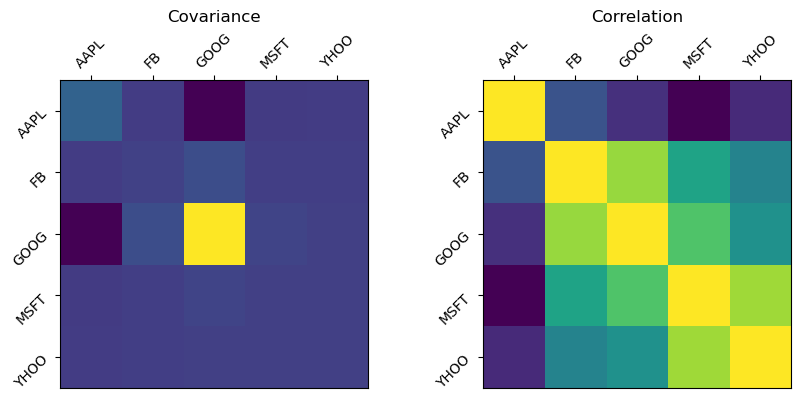

In [48]:
# Calculate the covariance and corealtion matrix using pandas
cov_matrix_pd = matrix.cov()
corr_matrix_pd = matrix.corr()

fig, ax = plt.subplots(1, 2, figsize=(10,4))
ax[0].set_title('Covariance')
ax[0].imshow(cov_matrix_pd)

ax[1].set_title('Correlation')
ax[1].imshow(corr_matrix_pd)

for i in [0, 1]:
    ax[i].xaxis.tick_top()
    ax[i].set_xticks(np.arange(len(labels)))
    ax[i].set_xticklabels(labels, rotation=45)
    ax[i].set_yticks(np.arange(len(labels)))
    ax[i].set_yticklabels(labels, rotation=45)

plt.show()

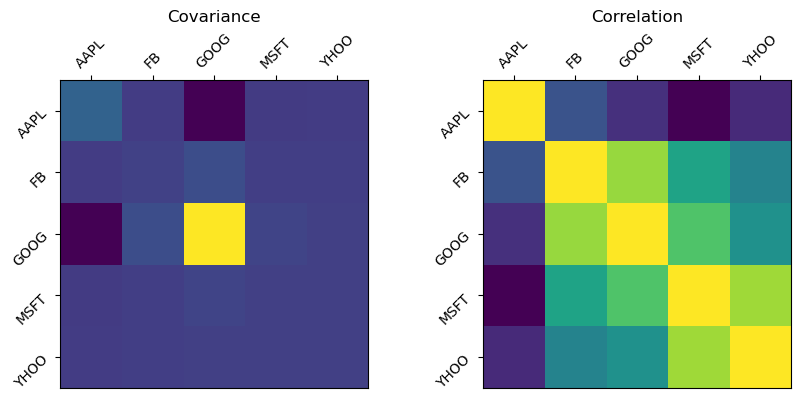

In [32]:
# Calculate the covariance and correlation matrix using the numpy library
cov_matrix = np.cov(matrix.values.T)
corr_matrix = np.corrcoef(matrix.values.T)

fig, ax = plt.subplots(1, 2, figsize=(10,4))
ax[0].set_title('Covariance')
ax[0].imshow(cov_matrix)

ax[1].set_title('Correlation')
ax[1].imshow(corr_matrix)

for i in [0, 1]:
    ax[i].xaxis.tick_top()
    ax[i].set_xticks(np.arange(len(labels)))
    ax[i].set_xticklabels(labels, rotation=45)
    ax[i].set_yticks(np.arange(len(labels)))
    ax[i].set_yticklabels(labels, rotation=45)

plt.show()

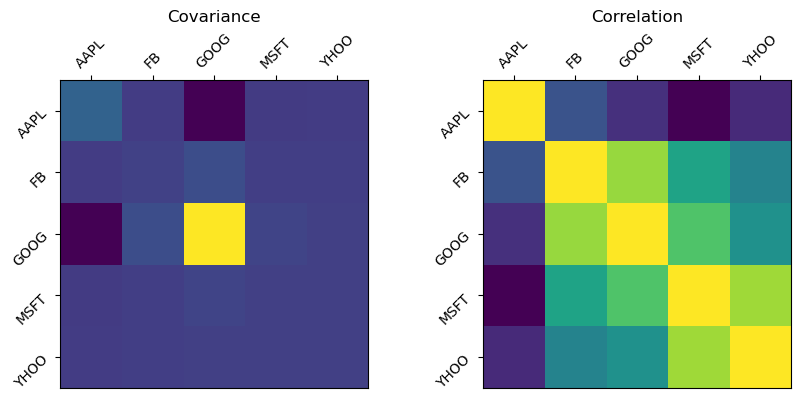

In [49]:
# Calculate the covariance and correlation matrix using linear algebra
# Mean center the cols
matrix_centered = matrix.values - np.mean(matrix.values, axis=0)

# Covariance matrix
cov_matrix_lin = (matrix_centered.T @ matrix_centered) / (matrix_centered.shape[0] - 1)

# Correlation matrix
std_matrix_lin = np.sqrt(np.diag(cov_matrix_lin))
corr_matrix_lin = cov_matrix_lin / np.outer(std_matrix_lin, std_matrix_lin)


fig, ax = plt.subplots(1, 2, figsize=(10,4))
ax[0].set_title('Covariance')
ax[0].imshow(cov_matrix_lin)

ax[1].set_title('Correlation')
ax[1].imshow(corr_matrix_lin)

for i in [0, 1]:
    ax[i].xaxis.tick_top()
    ax[i].set_xticks(np.arange(len(labels)))
    ax[i].set_xticklabels(labels, rotation=45)
    ax[i].set_yticks(np.arange(len(labels)))
    ax[i].set_yticklabels(labels, rotation=45)

plt.show()